# 使用http的方式与opencode交互

# https://opencode.ai/docs/zh-cn/server/ 
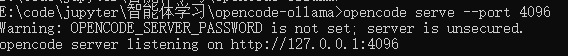

In [2]:
import requests
import json
BASE_URL = "http://localhost:4096"

# 1. 会话操作

### 1.1 创建一个会话

请求体：{ parentID?, title? }，返回 Session

In [20]:
# 创建会话
'''
r = requests.post(
    f"{BASE_URL}/session",
    json={
        "title": "测试会话创建"
    }
)
print(r.json())
'''

def creat_session(BASE_URL, title):
    r = requests.post(
        f"{BASE_URL}/session",
        json={
            "title": title
        }
    )
    session = r.json()
    return session

session = creat_session(BASE_URL, '测试1')
print('创建的会话：\n', session)
print('-------------------------------\n')
print('会话id(后续需要指定的重要标识)：\n', session['id'])

创建的会话：
 {'id': 'ses_0caca217dffetiTX3zD9DrsQgj', 'slug': 'neon-pixel', 'version': '1.3.17', 'projectID': 'global', 'directory': 'E:\\code\\jupyter\\智能体学习\\opencode-ollama', 'title': '测试', 'time': {'created': 1783304150658, 'updated': 1783304150658}}
-------------------------------

会话id(后续需要指定的重要标识)：
 ses_0caca217dffetiTX3zD9DrsQgj


### 1.2 列出所有会话

返回 Session[]

In [28]:
# 列出所有会话

'''
r = requests.get(
    f"{BASE_URL}/session",
)
print(r.json())
'''

def get_session(BASE_URL):
    r = requests.get(f"{BASE_URL}/session")
    sessions = r.json()
    simplified_sessions = []
    for session in sessions:
        simplified_sessions.append({
            'id': session.get('id'),
            'title': session.get('title'),
            'directory': session.get('directory')
        })
    return simplified_sessions


session_all = get_session(BASE_URL)
print('会话列表：\n', session_all)
print('-----------------------\n')

for s in session_all:
    print('会话id:', s['id'], ' 会话题目:' , s['title'] )
    print('\n')


会话列表：
 [{'id': 'ses_0caca217dffetiTX3zD9DrsQgj', 'title': '测试', 'directory': 'E:\\code\\jupyter\\智能体学习\\opencode-ollama'}, {'id': 'ses_0caca694bffexVUyT1HAq2cSFp', 'title': '测试', 'directory': 'E:\\code\\jupyter\\智能体学习\\opencode-ollama'}, {'id': 'ses_0cacaf2c4ffeAdG7y4S6pL8D3E', 'title': '测试', 'directory': 'E:\\code\\jupyter\\智能体学习\\opencode-ollama'}, {'id': 'ses_276618515ffeOuK23M4Hc1bFIU', 'title': '测试', 'directory': 'E:\\code\\opencode\\application_book'}]
-----------------------

会话id: ses_0caca217dffetiTX3zD9DrsQgj  会话题目: 测试


会话id: ses_0caca694bffexVUyT1HAq2cSFp  会话题目: 测试


会话id: ses_0cacaf2c4ffeAdG7y4S6pL8D3E  会话题目: 测试


会话id: ses_276618515ffeOuK23M4Hc1bFIU  会话题目: 测试




### 1.3 删除会话

返回 boolean

In [31]:
# 删除会话

'''
r = requests.delete(
    f"{BASE_URL}/session/ses_36bd804f5ffeD6CRGim429y2AQ",
)
print(r.json())
'''

def delete_session(BASE_URL, session_id):
    r = requests.delete(f"{BASE_URL}/session/{session_id}")
    return r.json()


session = get_session(BASE_URL)
# 删除所有会话
for s in session:
    s_id = s['id']
    print('\n删除会话：', s_id)
    delete_session(BASE_URL, s_id)


删除会话： ses_0caca217dffetiTX3zD9DrsQgj

删除会话： ses_0caca694bffexVUyT1HAq2cSFp

删除会话： ses_0cacaf2c4ffeAdG7y4S6pL8D3E

删除会话： ses_276618515ffeOuK23M4Hc1bFIU


# 2.配置文件操作
（只需要配置时查看，用于供应商设置，设置完成后不需要二次修改）

### 2.1 查看skills

In [37]:
# 查看有什么agent（skills）
r = requests.get(
    f"{BASE_URL}/agent",
)
print(r.json()[1])

{'name': 'compaction', 'mode': 'primary', 'native': True, 'hidden': True, 'prompt': 'You are a helpful AI assistant tasked with summarizing conversations.\n\nWhen asked to summarize, provide a detailed but concise summary of the conversation.\nFocus on information that would be helpful for continuing the conversation, including:\n- What was done\n- What is currently being worked on\n- Which files are being modified\n- What needs to be done next\n- Key user requests, constraints, or preferences that should persist\n- Important technical decisions and why they were made\n\nYour summary should be comprehensive enough to provide context but concise enough to be quickly understood.\n\nDo not respond to any questions in the conversation, only output the summary.\nRespond in the same language the user used in the conversation.\n', 'permission': [{'permission': '*', 'action': 'allow', 'pattern': '*'}, {'permission': 'doom_loop', 'action': 'ask', 'pattern': '*'}, {'permission': 'external_direct

### 2.2 供应商查看(*opencode模型请求*)

opencode.json中可以指定多种供应商，在这里查询，得到关键的智能体模型配置信息{model，modelID，providerID}，在消息中需要使用该参数
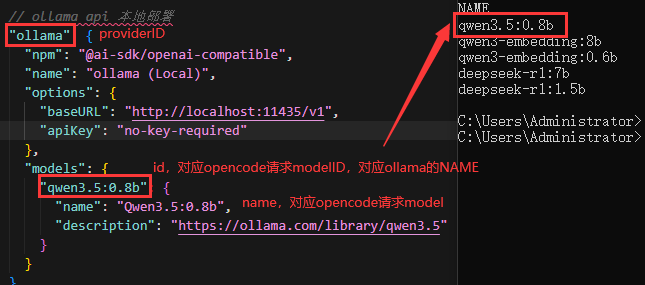

In [14]:
# 查看模型供应商
r = requests.get(
    f"{BASE_URL}/provider",
)
r = r.json()['all']


result = []
for provider in r:
    models = provider.get("models", {})

    for model_key, model_obj in models.items():
        result.append({
            "id": model_obj.get("id"),
            "providerID": model_obj.get("providerID"),
            "name": model_obj.get("name"),
        })

        
print(result)


[{'id': 'xai/grok-4', 'providerID': 'requesty', 'name': 'Grok 4'}, {'id': 'xai/grok-4-fast', 'providerID': 'requesty', 'name': 'Grok 4 Fast'}, {'id': 'google/gemini-2.5-pro', 'providerID': 'requesty', 'name': 'Gemini 2.5 Pro'}, {'id': 'google/gemini-2.5-flash', 'providerID': 'requesty', 'name': 'Gemini 2.5 Flash'}, {'id': 'google/gemini-3-pro-preview', 'providerID': 'requesty', 'name': 'Gemini 3 Pro'}, {'id': 'google/gemini-3-flash-preview', 'providerID': 'requesty', 'name': 'Gemini 3 Flash'}, {'id': 'openai/gpt-5.2-chat', 'providerID': 'requesty', 'name': 'GPT-5.2 Chat'}, {'id': 'openai/gpt-5.2-pro', 'providerID': 'requesty', 'name': 'GPT-5.2 Pro'}, {'id': 'openai/gpt-5', 'providerID': 'requesty', 'name': 'GPT-5'}, {'id': 'openai/gpt-5-chat', 'providerID': 'requesty', 'name': 'GPT-5 Chat (latest)'}, {'id': 'openai/gpt-5-pro', 'providerID': 'requesty', 'name': 'GPT-5 Pro'}, {'id': 'openai/o4-mini', 'providerID': 'requesty', 'name': 'o4 Mini'}, {'id': 'openai/gpt-5.1-chat', 'providerID'

In [15]:
#查询供应商
def find_by_name(models, target_name):
    for m in models:
        if m.get("name") == target_name:
            print(m)
    return None

result_name = find_by_name(result, "deepseek-v4-pro")
print(result_name)

result_name = find_by_name(result, "Big Pickle")
print(result_name)

{'id': 'deepseek-v4-pro', 'providerID': 'ollama-cloud', 'name': 'deepseek-v4-pro'}
{'id': 'deepseek-v4-pro', 'providerID': 'WenModel', 'name': 'deepseek-v4-pro'}
None
{'id': 'big-pickle', 'providerID': 'opencode', 'name': 'Big Pickle'}
None


# 3. 消息

In [83]:
session = creat_session(BASE_URL, 'ppt')
session_id = session['id']

### 3.1 得到历史上下文
查询参数：limit?，返回 { info: Message, parts: Part[]}[]

In [123]:
# 得到上下文，显示对话
r = requests.get(
    f"{BASE_URL}/session/{session_id}/message",
)
print(r.json())
print('------------------\n \n')


def get_session_context(session_id):
    r = requests.get(
        f"{BASE_URL}/session/{session_id}/message",
    )
    messages = r.json()

    context = []
    for msg in messages:
        info = msg.get("info", {})
        parts = msg.get("parts", [])
        role = info.get("role", "unknown")
        text_parts = []
        for part in parts:
            if part.get("type") == "text":
                text = part.get("text", "")
                if text:
                    text_parts.append(text)
        if text_parts:
            context.append({
                "role": role,
                "content": "\n".join(text_parts)
            })
    return context
                    
                
context = get_session_context(session_id)  
for c in context:
    print(c["role"],':',c["content"],'\n')
    print('-----------\n')


[{'info': {'role': 'user', 'time': {'created': 1783305906443}, 'agent': 'general', 'model': {'providerID': 'ollama', 'modelID': 'qwen3.5:0.8b'}, 'summary': {'diffs': []}, 'id': 'msg_f3550a90b001QmwGyfxsuyegl9', 'sessionID': 'ses_0caaf5ff5ffeGs6kFv07zl4Mwr'}, 'parts': [{'type': 'text', 'text': '你有哪些skills', 'id': 'prt_f3550a90c001pNToO5MP3p7S3G', 'sessionID': 'ses_0caaf5ff5ffeGs6kFv07zl4Mwr', 'messageID': 'msg_f3550a90b001QmwGyfxsuyegl9'}]}, {'info': {'parentID': 'msg_f3550a90b001QmwGyfxsuyegl9', 'role': 'assistant', 'mode': 'general', 'agent': 'general', 'path': {'cwd': 'E:\\code\\jupyter\\智能体学习\\opencode-ollama', 'root': '/'}, 'cost': 0, 'tokens': {'total': 2158, 'input': 2050, 'output': 108, 'reasoning': 0, 'cache': {'write': 0, 'read': 0}}, 'modelID': 'qwen3.5:0.8b', 'providerID': 'ollama', 'time': {'created': 1783305906719, 'completed': 1783305999976}, 'finish': 'stop', 'id': 'msg_f3550aa1f001puK5uXG5FC6vV7', 'sessionID': 'ses_0caaf5ff5ffeGs6kFv07zl4Mwr'}, 'parts': [{'type': 'step-

### 3.2 单次发送消息请求
请求体：{ messageID?, model?, agent?, noReply?, system?, tools?, parts }，返回 { info: Message, parts: Part[]}


In [121]:
import requests
from typing import Optional, Dict, List, Any

#model = {'model':'Big Pickle', 'modelID': 'big-pickle', 'providerID': 'opencode'}
model = {'model':'Qwen3.5:0.8b', 'modelID': 'qwen3.5:0.8b', 'providerID': 'ollama'}
#model = {'model':'MiniMax M2.5 Free', 'modelID': 'minimax-m2.5-free', 'providerID': 'opencode'}


def send_message(
        BASE_URL: str,
        session_id: str,
        message: str,
        agent: Optional[str] = None, 
        model: Optional[str] = None,
        no_reply: bool = False
    ) -> Dict[str, Any]:
       
    data = {
        "parts": [{"type": "text", "text": message}]
    }
    if agent:
        data["agent"] = agent
    if model:
        data["model"] = model
    if no_reply:
        data["noReply"] = True

    r = requests.post(
        f"{BASE_URL}/session/{session_id}/message",
        json=data
    )
    
    return r.json()

session_id = session['id']
a = send_message(BASE_URL, session_id, "测试", "general", model)
print(a)

{'info': {'parentID': 'msg_f3572803d001qpz3VUbTOC3U7K', 'role': 'assistant', 'mode': 'general', 'agent': 'general', 'path': {'cwd': 'E:\\code\\jupyter\\智能体学习\\opencode-ollama', 'root': '/'}, 'cost': 0, 'tokens': {'total': 2118, 'input': 2050, 'output': 68, 'reasoning': 0, 'cache': {'write': 0, 'read': 0}}, 'modelID': 'qwen3.5:0.8b', 'providerID': 'ollama', 'time': {'created': 1783308124226, 'completed': 1783308178631}, 'finish': 'stop', 'id': 'msg_f357280420012vefMijB3pemxS', 'sessionID': 'ses_0caaf5ff5ffeGs6kFv07zl4Mwr'}, 'parts': [{'type': 'step-start', 'id': 'prt_f35734169001ADqcHsX5a6jSyY', 'sessionID': 'ses_0caaf5ff5ffeGs6kFv07zl4Mwr', 'messageID': 'msg_f357280420012vefMijB3pemxS'}, {'type': 'reasoning', 'text': '用户希望我进行一些代码测试或系统检查，没有提供具体的请求内容。我需要解释我的状态并询问具体要做什么以便提供帮助。', 'time': {'start': 1783308173683, 'end': 1783308175956}, 'id': 'prt_f35734173001i5iypxJTe9MEiX', 'sessionID': 'ses_0caaf5ff5ffeGs6kFv07zl4Mwr', 'messageID': 'msg_f357280420012vefMijB3pemxS'}, {'type': 'text', 'text

### 3.3 异步发送消息（不等待响应）

结束标致：info.finish 是 "stop"，part含有{"type": "step-finish", "reason": "stop"}



In [134]:
import time
import requests
from typing import Optional, Dict, List, Any

BASE_URL = "http://127.0.0.1:4096"
session = creat_session(BASE_URL, 'ppt')
session_id = session['id']
model = {'model':'Big Pickle', 'modelID': 'big-pickle', 'providerID': 'opencode'}


# 异步发送消息
def send_async_message(
    message: str,
    BASE_URL: str,
    session_id: str,
    agent: Optional[str] = "general", 
    model: Optional[str] = None,
):
    data = {
        "parts": [{"type": "text", "text": message}]
    }
    if agent:
        data["agent"] = agent
    if model:
        data["model"] = model
    
    r = requests.post(
        f"{BASE_URL}/session/{session_id}/prompt_async",
        json=data,
        timeout=50
    )
    print("消息已发送")
    return r


# 得到响应
def stream_output(interval=5):
    printed_text_lens = {}   
    last_message_id = None
    printed_tool_ids = set()

    while True:
        try:
            r = requests.get(
                f"{BASE_URL}/session/{session_id}/message",
                timeout=30
            )
            r.raise_for_status()
            messages = r.json()
            print('-------------------')
            print('messages:',messages)
            print('-------------------')

            if not messages:
                time.sleep(interval)
                continue

            # 找最后一条 assistant 消息
            assistant_msg = None
            for msg in reversed(messages):
                if msg.get("info", {}).get("role") == "assistant":
                    assistant_msg = msg
                    break

            if not assistant_msg:
                time.sleep(interval)
                continue

            message_id = assistant_msg["info"]["id"]

            # 新 assistant 消息，重置状态
            if message_id != last_message_id:
                printed_text_lens = {}
                printed_tool_ids = set()
                tool_stdout_emitted = set()
                last_message_id = message_id
                print(f"\n===== assistant message: {message_id} =====")

            finished = False

            for part in assistant_msg.get("parts", []):
                part_id = part.get("id")
                part_type = part.get("type")

                if not part_id:
                    continue

                # 处理文本信息
                if part_type in ("reasoning", "text"):
                    current_text = part.get("text", "") or ""
                    old_len = printed_text_lens.get(part_id, 0)

                    # 只打印新增部分
                    if len(current_text) > old_len:
                        delta = current_text[old_len:]

                        if old_len == 0:
                            if part_type == "reasoning":
                                print(f"\n[reasoning] ", end="", flush=True)
                            else:
                                print(f"\n[text] ", end="", flush=True)

                        print(delta, end="", flush=True)
                        printed_text_lens[part_id] = len(current_text)
        
                # 处理tool信息
                elif part_type == "tool":
                    if part_id in printed_tool_ids:
                        continue
                    printed_tool_ids.add(part_id)
                
                    tool_name = part.get("tool")
                    state = part.get("state", {}) or {}
                    status = state.get("status")

                    # 处理bash等脚本信息，放在reasoning中一起输出
                    if status == "completed" and tool_name in ("bash", "shell"):
                        if part_id not in tool_stdout_emitted:
                            tool_stdout_emitted.add(part_id)
                            meta = state.get("metadata") or {}
                            raw_out = meta.get("output") or state.get("output") or ""
                            if isinstance(raw_out, str) and raw_out.strip():
                                snippet = raw_out.strip()
                                block = f"\n\n【命令输出】\n{snippet}\n"
                                print("\n[reasoning] " + block[:500] + ("…" if len(block) > 500 else ""), flush=True)
                        
                
                elif part_type == "step-finish":
                    finished = True

            if finished:
                print("\n\n--- 完成 ---")
                break

        except Exception as e:
            print("查询失败：", e)
        time.sleep(interval)

# 使用
send_async_message("你有哪些skills？请全部列出来，并写一个简单的skills", BASE_URL, session_id, None, model)
stream_output(interval=10)

消息已发送
-------------------
messages: [{'info': {'role': 'user', 'time': {'created': 1783309551864}, 'agent': 'build', 'model': {'providerID': 'opencode', 'modelID': 'big-pickle'}, 'summary': {'diffs': []}, 'id': 'msg_f358848f8001sWvftWYhVEWS9g', 'sessionID': 'ses_0ca77b78dffeSMtR42PIdgxTq5'}, 'parts': [{'type': 'text', 'text': '你有哪些skills？请全部列出来，并写一个简单的skills', 'id': 'prt_f358848f8002TcKoM0rs2T9E4A', 'sessionID': 'ses_0ca77b78dffeSMtR42PIdgxTq5', 'messageID': 'msg_f358848f8001sWvftWYhVEWS9g'}]}, {'info': {'parentID': 'msg_f358848f8001sWvftWYhVEWS9g', 'role': 'assistant', 'mode': 'build', 'agent': 'build', 'path': {'cwd': 'E:\\code\\jupyter\\智能体学习\\opencode-ollama', 'root': '/'}, 'cost': 0, 'tokens': {'input': 0, 'output': 0, 'reasoning': 0, 'cache': {'read': 0, 'write': 0}}, 'modelID': 'big-pickle', 'providerID': 'opencode', 'time': {'created': 1783309551913}, 'id': 'msg_f35884929001MpBSl4VGnmNeW3', 'sessionID': 'ses_0ca77b78dffeSMtR42PIdgxTq5'}, 'parts': []}]
-------------------

=====

### 异步发送消息与前端结合（使用SSE的方式让前端逐行输出）

In [165]:
import time
import json
import requests
from typing import Optional, Any


BASE_URL = "http://127.0.0.1:4096"

session = creat_session(BASE_URL, "ppt")
session_id = session["id"]

model = {
    "model": "Big Pickle",
    "modelID": "big-pickle",
    "providerID": "opencode"
}


# 异步发送消息
def send_async_message(
    message: str,
    BASE_URL: str,
    session_id: str,
    agent: Optional[str] = "general",
    model: Optional[Any] = None,
):
   
    data = {
        "parts": [
            {
                "type": "text",
                "text": message
            }
        ]
    }

    if agent:
        data["agent"] = agent

    if model:
        data["model"] = model

    r = requests.post(
        f"{BASE_URL}/session/{session_id}/prompt_async",
        json=data,
        timeout=50
    )

    r.raise_for_status()

    print("消息已发送")

    return r


def sse_pack(data, msg_type="output"):
    """
    将内容包装成 SSE 格式。

    这里使用 JSON，而不是普通文本，原因：
    1. 避免 Markdown 换行导致多个空 data:
    2. 前端可以区分 reasoning / output / done
    3. 表格、代码块、列表等 Markdown 内容不会被破坏

    返回格式示例：
        data: {"type": "output", "content": "你好"}

    """

    payload = {
        "type": msg_type,
        "content": data if data is not None else ""
    }

    return f"data: {json.dumps(payload, ensure_ascii=False)}\n\n"


def stream_output(
    message: str,
    BASE_URL: str,
    session_id: str,
    agent: Optional[str] = "general",
    model: Optional[Any] = None,
    interval: float = 0.3,
):
    """
    发送用户消息，并实时获取 OpenCode 回复。

    返回给前端的 SSE 数据类型：
        1. reasoning：思维链 / 推理过程
        2. output：最终回答
        3. done：本轮回答结束

    本轮问答结束标志：
        info["finish"] == "stop"

    注意：
        finish == "tool-calls" 不是最终结束。
        它只表示模型调用了工具，后面还会继续生成 assistant 消息。
    """

    # 1. 发送前，先获取已有消息，记录旧 message id
    old_r = requests.get(
        f"{BASE_URL}/session/{session_id}/message",
        timeout=50
    )
    old_r.raise_for_status()

    old_messages = old_r.json()

    old_message_ids = set()

    for msg in old_messages:
        msg_id = msg.get("info", {}).get("id")
        if msg_id:
            old_message_ids.add(msg_id)

    # 2. 异步发送新消息，可指定 agent 和 model
    send_async_message(
        message=message,
        BASE_URL=BASE_URL,
        session_id=session_id,
        agent=agent,
        model=model
    )

    # 已经输出过的 reasoning 内容
    printed_reasoning = ""

    # 已经输出过的 output 内容
    printed_output = ""

    while True:
        # 3. 轮询获取当前会话消息
        r = requests.get(
            f"{BASE_URL}/session/{session_id}/message",
            timeout=50
        )
        r.raise_for_status()

        messages = r.json()

        # 当前轮次累计 reasoning
        current_reasoning = ""

        # 当前轮次累计 output
        current_output = ""

        # 当前轮次是否结束
        finished = False

        # 4. 遍历新产生的 assistant 消息
        for msg in messages:
            info = msg.get("info", {})
            parts = msg.get("parts", [])

            msg_id = info.get("id")
            role = info.get("role")
            finish = info.get("finish")

            # 跳过发送前已有的旧消息
            if msg_id in old_message_ids:
                continue

            # 只处理 assistant 消息
            if role != "assistant":
                continue

            # 5. 解析 reasoning 和 output
            for part in parts:
                part_type = part.get("type")

                # OpenCode 返回的 reasoning
                if part_type == "reasoning":
                    reasoning_text = part.get("text", "")
                    if reasoning_text:
                        if current_reasoning:
                            current_reasoning += "\n\n"
                        current_reasoning += reasoning_text

                # OpenCode 返回的最终回答文本
                elif part_type == "text":
                    output_text = part.get("text", "")
                    if output_text:
                        if current_output:
                            current_output += "\n\n"
                        current_output += output_text

                # 备用结束标志
                elif part_type == "step-finish":
                    if part.get("reason") == "stop":
                        finished = True

            # 主要结束标志
            if finish == "stop":
                finished = True

        # 6. 输出 reasoning 增量
        if current_reasoning.startswith(printed_reasoning):
            reasoning_delta = current_reasoning[len(printed_reasoning):]
        else:
            reasoning_delta = current_reasoning

        if reasoning_delta:
            if not printed_reasoning:
                print("\n[reasoning]\n", end="", flush=True)

            print(reasoning_delta, end="", flush=True)

            yield sse_pack(reasoning_delta, msg_type="reasoning")

            printed_reasoning = current_reasoning

        # 7. 输出 output 增量
        if current_output.startswith(printed_output):
            output_delta = current_output[len(printed_output):]
        else:
            output_delta = current_output

        if output_delta:
            if not printed_output:
                print("\n[output]\n", end="", flush=True)

            print(output_delta, end="", flush=True)

            yield sse_pack(output_delta, msg_type="output")

            printed_output = current_output

        # 8. 如果本轮回答结束，退出循环
        if finished:
            print("\n[DONE]")

            yield sse_pack("", msg_type="done")

            break

        time.sleep(interval)

In [168]:
for chunk in stream_output(
    message="1.介绍一下你自己. 2.说明你有什么skills，用表格列出来 3.判断2+3等于多少 4.使用skills制作一个ppt",
    BASE_URL=BASE_URL,
    session_id=session_id,
    agent="general",
    model=model
):
    print("\n------------\n 收到 chunk:\n", chunk, '---------------\n')

消息已发送

[reasoning]
The user is asking me to:
1. Introduce myself
2. List my skills in a table
3. Calculate 2+3
4. Use skills to make a PPT

Let me address each:

1. I'm opencode, an AI assistant for software engineering tasks.
2. I should list my skills/abilities in a table format.
3. 2+3 = 5
4. The user wants me to use the "skill-creator" skill to make a PPT. Wait, let me re-read this. The user says "使用skills制作一个ppt" - this likely means using the available skills (the skill-creator skill) to make a PPT. But the skill-creator is for creating skills, not PPTs. 

Actually, looking more carefully, I think the user might be referring to the skills listed in the system prompt (the available_skills section) and asking me to use one of those skills. But the only skill available is "skill-creator" which is for creating skill definitions.

Or perhaps the user is testing me - they want me to list my capabilities (skills), and then use those skills to make a PPT. But I already made a PPT for them

In [167]:
for chunk in stream_output(
    message="做一个1页的自我介绍ppt",
    BASE_URL=BASE_URL,
    session_id=session_id,
    agent="general",
    model=model
):
    print("收到 chunk:", chunk)

消息已发送

[reasoning]
The user wants me to create a 1-page self-introduction PPT. I need to create a PowerPoint file. Let me first check what's in the working directory, then create the PPT.

I can use python-pptx library to create this. Let me check if it's available first.收到 chunk: data: {"type": "reasoning", "content": "The user wants me to create a 1-page self-introduction PPT. I need to create a PowerPoint file. Let me first check what's in the working directory, then create the PPT.\n\nI can use python-pptx library to create this. Let me check if it's available first."}




Good, python-pptx is available. Now let me create a nice 1-page self-introduction PPT. I'll create a modern, clean design with:

1. Name
2. Title/Role
3. Brief intro
4. Contact info
5. Skills or other sections

Let me write a Python script to generate it.收到 chunk: data: {"type": "reasoning", "content": "\n\nGood, python-pptx is available. Now let me create a nice 1-page self-introduction PPT. I'll create a modern

In [ ]:
# django中的后端
from django.http import StreamingHttpResponse, JsonResponse
from django.views.decorators.http import require_GET

from .opencode_client import stream_output


BASE_URL = "http://localhost:4096"


@require_GET
def chat_stream(request):
    """
    Django 流式聊天接口。

    前端请求示例：
    /chat/stream/?session_id=xxx&message=你好&agent=general&model=qwen3.5:0.8b
    """

    session_id = request.GET.get("session_id")
    message = request.GET.get("message")

    # agent 可选，默认 general
    agent = request.GET.get("agent", "general")

    # model 可选，不传则使用 OpenCode 默认模型
    model = request.GET.get("model")

    if not session_id:
        return JsonResponse({"error": "缺少 session_id"}, status=400)

    if not message:
        return JsonResponse({"error": "缺少 message"}, status=400)

    response = StreamingHttpResponse(
        streaming_content=stream_output(
            message=message,
            BASE_URL=BASE_URL,
            session_id=session_id,
            agent=agent,
            model=model
        ),
        content_type="text/event-stream"
    )

    # 禁止浏览器缓存，保证实时输出
    response["Cache-Control"] = "no-cache"

    # 如果后面用 Nginx 部署，这行可以关闭缓冲
    response["X-Accel-Buffering"] = "no"

    return response